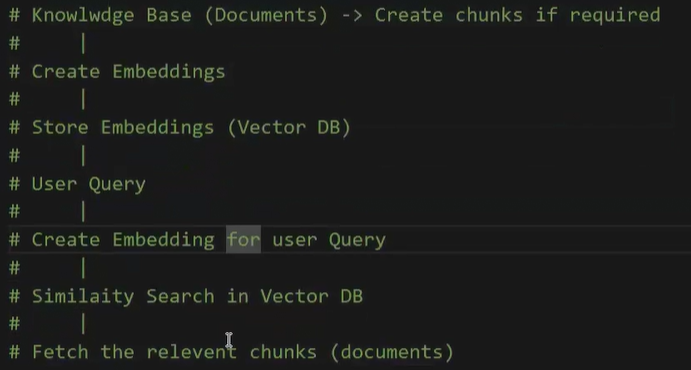

In [1]:
## Basic AI Pipeline:
# Query + LLM -> Output


## RAG Pipieline:

#   Query
#     |
# Fetch the Relevant Chunk (document) (Retriever)
#     |
# Add this retrieved document as context to the LLM
#     |
# Create Prompt (context + query)
#     |
# LLM Call

## Retriever using Python (linear search)

In [2]:
# It is a tool (function) that fetches or retrieves the relevant chunk (document) from the knowledge base.

In [3]:
import numpy as np
from openai import OpenAI
import os

In [4]:
llm_client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))
llm_client

### Step 1: Create/Get Chunks

In [5]:
chunks = [
    "Python is a programming language used for AI and machine learning.",
    "ChromaDB is a vector database used in retrieval augmented generation.",
    "Embeddings convert text into numerical vectors.",
    "FAISS is a library developed by Facebook for fast similarity search.",
    "Neural networks are used in deep learning applications."
]

### Step 2: Create Embeddings of Chunks

In [6]:
def get_embeddings(llm_client, text):
    response = llm_client.embeddings.create(
        model='text-embedding-3-small',
        input=text
    )

    return response.data[0].embedding

In [7]:
embeddings = []

for chunk in chunks:
    embedding = get_embeddings(llm_client=llm_client, text=chunk)
    embeddings.append(embedding)

In [8]:
chunk_embeddings = np.array(embeddings)
chunk_embeddings

array([[-0.02275337, -0.01865853, -0.00778888, ..., -0.05883426,
        -0.0114636 ,  0.0031339 ],
       [ 0.03462372,  0.06587309,  0.04706967, ..., -0.0065653 ,
         0.02094295, -0.01435319],
       [-0.02061875,  0.01605718,  0.03773037, ..., -0.01034949,
        -0.00361888,  0.0410312 ],
       [-0.03680114, -0.02335072, -0.00020274, ...,  0.04375136,
        -0.04630144,  0.00078792],
       [-0.03863996, -0.03416201, -0.00301906, ...,  0.01090105,
         0.02567217,  0.02392962]], shape=(5, 1536))

### Step 3: Similarity Search

In [9]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [10]:
np.argsort([2,1,3,-1]) # returns the indices in ascending order (-1, 1, 2, 3)

array([3, 1, 0, 2])

In [11]:
np.argsort([2,1,3,-1])[::-1] # reversing the array to get the values in descending order (3, 2, 1, -1)

array([2, 0, 1, 3])

### Step 4: Retriever

In [15]:
def retriever(query, chunks, chunk_embeddings, llm_client, top_k=2):
    # Create embedding for the user query
    query_emb = get_embeddings(llm_client=llm_client, text=query)

    # Similarity Search
    scores = []
    for chunk_emb in chunk_embeddings:
        score = cosine_similarity(query_emb, chunk_emb)
        scores.append(score)
    
    print(chunks)
    print(scores)

    # Sort Scores
    # Higher the score, higher the similarity
    sorted_indices = np.argsort(scores)[::-1]

    # Top Chunks
    top_chunks = []
    for index in sorted_indices[:top_k]:
        top_chunks.append(chunks[index])

    return top_chunks

### Step 5: Test Retriever

In [16]:
query = 'What is a Vector DB?'
results = retriever(query=query, chunks=chunks, chunk_embeddings=chunk_embeddings, llm_client=llm_client)

['Python is a programming language used for AI and machine learning.', 'ChromaDB is a vector database used in retrieval augmented generation.', 'Embeddings convert text into numerical vectors.', 'FAISS is a library developed by Facebook for fast similarity search.', 'Neural networks are used in deep learning applications.']
[np.float64(0.133727644555896), np.float64(0.5150434476793275), np.float64(0.35455138501409705), np.float64(0.1909726742369545), np.float64(0.20759654461364951)]


In [17]:
results

['ChromaDB is a vector database used in retrieval augmented generation.',
 'Embeddings convert text into numerical vectors.']

## Retriever using ChromaDB

### Step 1: Create ChromaDB & OpenAI Clients

In [18]:
import chromadb

In [19]:
openai_client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))
openai_client

In [20]:
# persistent client
db_client = chromadb.PersistentClient(path="./retriever_chroma_db")

### Step 2: Create Collections

In [21]:
collection = db_client.create_collection(name='retriever_documents')
collection

Collection(name=retriever_documents)

### Step 3: Add documents to the Collection

In [22]:
documents = [
    "Python is a programming language used for AI and machine learning.",
    "ChromaDB is a vector database used in retrieval augmented generation.",
    "Embeddings convert text into numerical vectors.",
    "FAISS is a library developed by Facebook for fast similarity search.",
    "Neural networks are used in deep learning applications."
]

In [23]:
collection.add(documents=documents,
               ids=['doc1', 'doc2', 'doc3', 'doc4', 'doc5'])

In [24]:
# If we don't pass embeddings, chromadb uses its own embedding model and creates vectors.

# documents (chunks)
#         |
# embedding model
#         |
# vectors created
#         |
# vectors and chunks added to collection

### Step 4: Query/Retrieval

In [27]:
db_results = collection.query(
    query_texts=query,
    n_results=2
)

In [30]:
db_results

# smaller the distance, closer the vectors. It internally uses the Cosine Similarity too but returns the Euclidian Distance

{'ids': [['doc2', 'doc3']],
 'embeddings': None,
 'documents': [['ChromaDB is a vector database used in retrieval augmented generation.',
   'Embeddings convert text into numerical vectors.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None]],
 'distances': [[1.0523319244384766, 1.3068033456802368]]}

In [34]:
collection.configuration_json

{'hnsw': {'space': 'l2',
  'ef_construction': 100,
  'ef_search': 100,
  'max_neighbors': 16,
  'resize_factor': 1.2,
  'sync_threshold': 1000},
 'spann': None,
 'embedding_function': {'type': 'known', 'name': 'default', 'config': {}}}

In [35]:
collection.schema

Schema(defaults=ValueTypes(string=StringValueType(fts_index=FtsIndexType(enabled=False, config=FtsIndexConfig()), string_inverted_index=StringInvertedIndexType(enabled=True, config=StringInvertedIndexConfig())), float_list=FloatListValueType(vector_index=VectorIndexType(enabled=False, config=VectorIndexConfig(space='l2', embedding_function=<chromadb.api.types.DefaultEmbeddingFunction object at 0x0000018431E434D0>, source_key=None, hnsw=HnswIndexConfig(ef_construction=100, max_neighbors=16, ef_search=100, num_threads=14, batch_size=100, sync_threshold=1000, resize_factor=1.2), spann=None))), sparse_vector=SparseVectorValueType(sparse_vector_index=SparseVectorIndexType(enabled=False, config=SparseVectorIndexConfig(embedding_function=None, source_key=None, bm25=False))), int_value=IntValueType(int_inverted_index=IntInvertedIndexType(enabled=True, config=IntInvertedIndexConfig())), float_value=FloatValueType(float_inverted_index=FloatInvertedIndexType(enabled=True, config=FloatInvertedInde

## RAG Architecture

In [36]:
# Retrieval -> Context
# Prompt -> Context + Query (Augmentation)
# Call LLM (Generator)

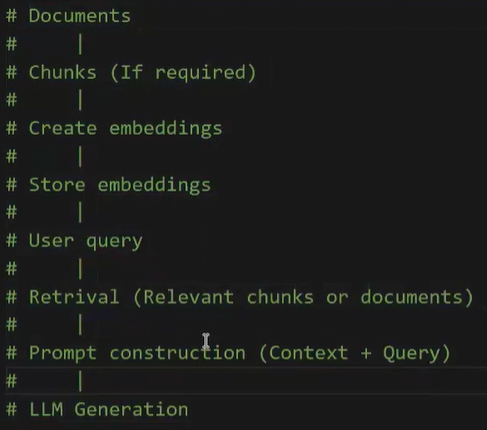

In [37]:
# We have covered till Retrieval part

### Step 5: Get Context from retriever

In [39]:
db_results['documents'][0]

['ChromaDB is a vector database used in retrieval augmented generation.',
 'Embeddings convert text into numerical vectors.']

In [41]:
context = '\n'.join(db_results['documents'][0])
print(context)

ChromaDB is a vector database used in retrieval augmented generation.
Embeddings convert text into numerical vectors.


### Step 6: Create Prompt

In [43]:
new_query = 'What is a Vector DB?'

In [45]:
prompt=f'''Answer the query based upon the given context only.
CONTEXT:
{context}
QUERY:
{new_query}
'''

print(prompt)

Answer the query based upon the given context only.
CONTEXT:
ChromaDB is a vector database used in retrieval augmented generation.
Embeddings convert text into numerical vectors.
QUERY:
What is a Vector DB?



### Step 7: LLM Call (Generation)

In [46]:
response = openai_client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role': 'user', 'content': prompt}]
)

In [51]:
print(response.choices[0].message.content)

A vector DB, or vector database, is a type of database designed to store and manage numerical vectors, which are often used to represent data such as text embeddings. These vectors enable efficient searching and retrieval of related information in applications like retrieval augmented generation.
